In [34]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files

# Machine Learning Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Oversampling for Imbalanced Data
from imblearn.over_sampling import RandomOverSampler

# Settings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [35]:
# ==========================================
# 2. DATA LOADING
# ==========================================
print("Step 1: Please upload 'cloud_task_scheduling_dataset.csv'")
uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

# Basic Cleaning
df = df.dropna().drop_duplicates()
print(f"Dataset Loaded. Shape: {df.shape}")

Step 1: Please upload 'cloud_task_scheduling_dataset.csv'


Saving cloud_task_scheduling_dataset.csv to cloud_task_scheduling_dataset (3).csv
Dataset Loaded. Shape: (1000, 9)


In [36]:
df.head()

,Task_ID,CPU_Usage (%),RAM_Usage (MB),Disk_IO (MB/s),Network_IO (MB/s),Priority,VM_ID,Execution_Time (s),Target (Optimal Scheduling)
0,1,37,2612,55,40,2,107,1.27,1
1,2,86,11761,55,12,3,106,3.71,1
2,3,44,4610,6,1,2,101,8.53,0
3,4,82,12604,29,18,3,106,7.31,0
4,5,59,15945,54,11,1,102,1.76,1


In [37]:
df.tail()

,Task_ID,CPU_Usage (%),RAM_Usage (MB),Disk_IO (MB/s),Network_IO (MB/s),Priority,VM_ID,Execution_Time (s),Target (Optimal Scheduling)
995,996,63,2005,89,21,3,108,8.11,0
996,997,52,7345,36,10,1,102,8.41,0
997,998,78,11638,30,1,1,102,6.29,0
998,999,35,2966,10,33,2,107,1.60,1
999,1000,60,826,13,13,1,109,9.93,0


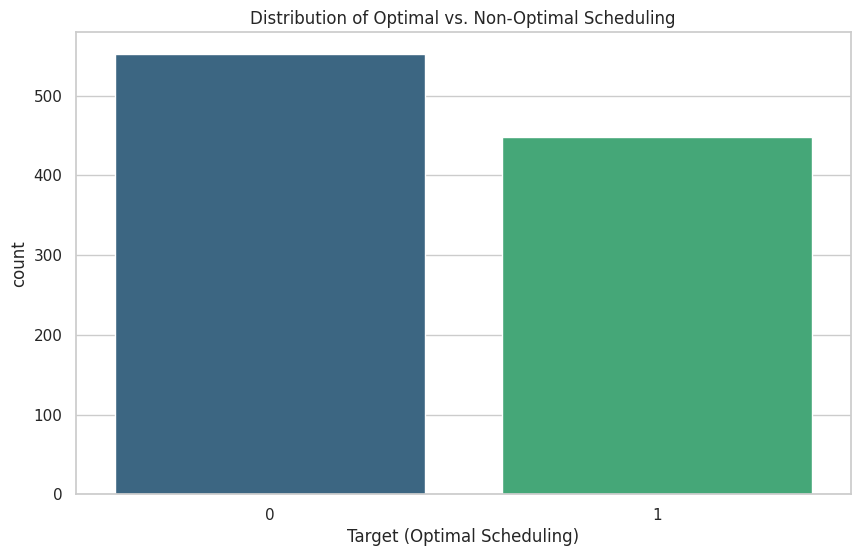

In [38]:
# EDA 1: Target Label Balance
plt.figure()
sns.countplot(x='Target (Optimal Scheduling)', data=df, palette='viridis')
plt.title('Distribution of Optimal vs. Non-Optimal Scheduling')
plt.show()

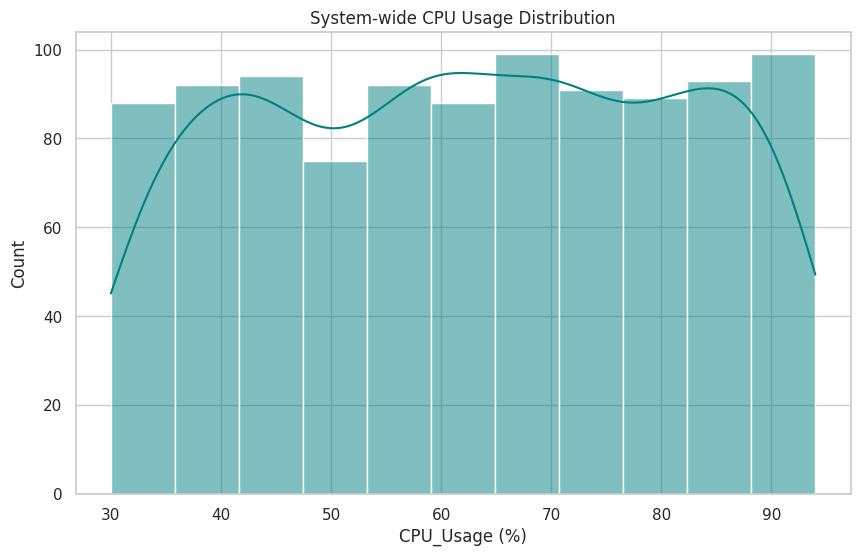

In [39]:
# EDA 2: CPU Usage Analysis
plt.figure()
sns.histplot(df['CPU_Usage (%)'], kde=True, color='teal')
plt.title('System-wide CPU Usage Distribution')
plt.show()

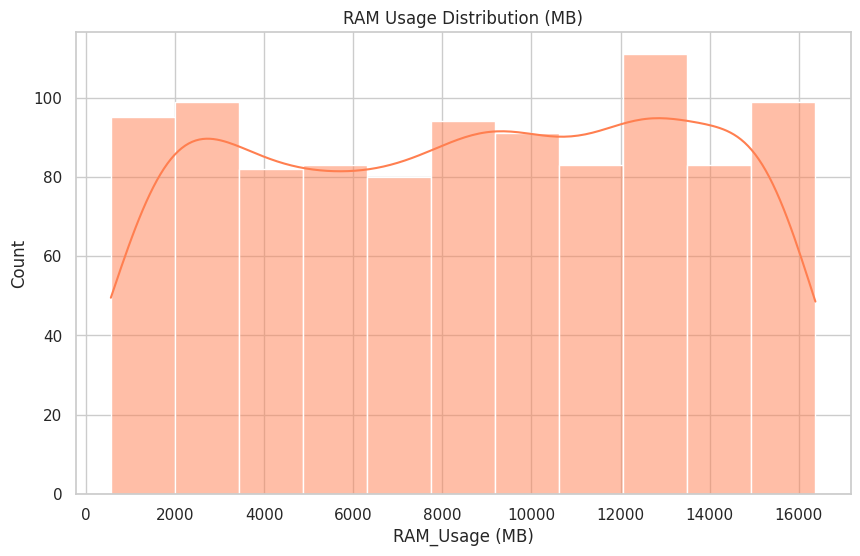

In [40]:
# EDA 3: Memory Footprint (RAM)
plt.figure()
sns.histplot(df['RAM_Usage (MB)'], kde=True, color='coral')
plt.title('RAM Usage Distribution (MB)')
plt.show()

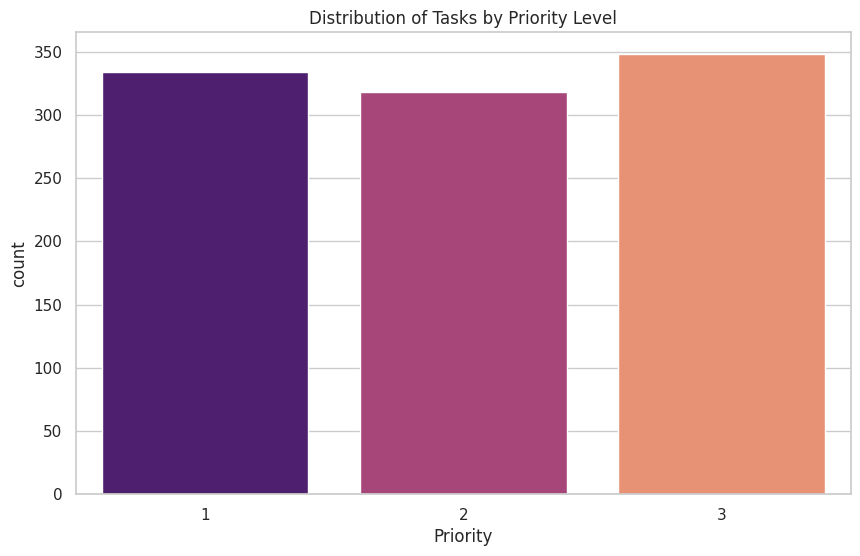

In [41]:
plt.figure()
sns.countplot(x='Priority', data=df, palette='magma')
plt.title('Distribution of Tasks by Priority Level')
plt.show()

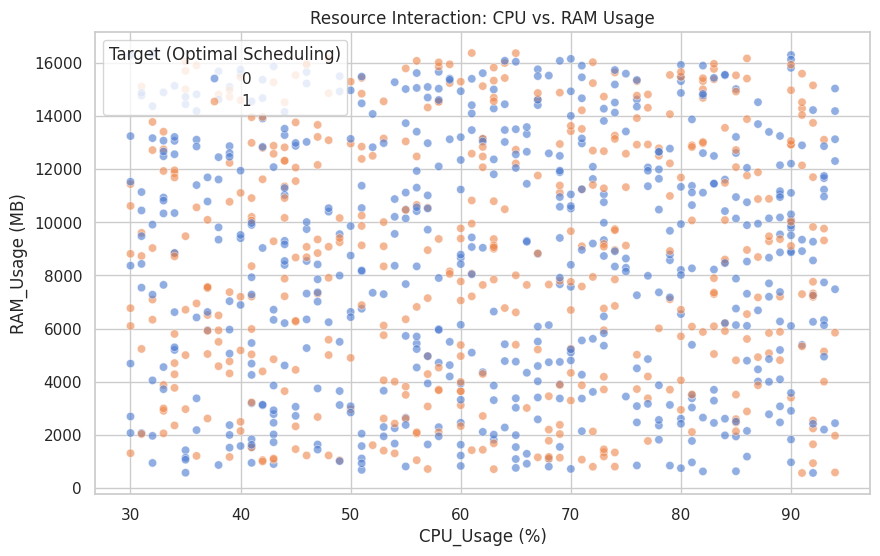

In [42]:
plt.figure()
sns.scatterplot(x='CPU_Usage (%)', y='RAM_Usage (MB)', hue='Target (Optimal Scheduling)', data=df, alpha=0.6)
plt.title('Resource Interaction: CPU vs. RAM Usage')
plt.show()

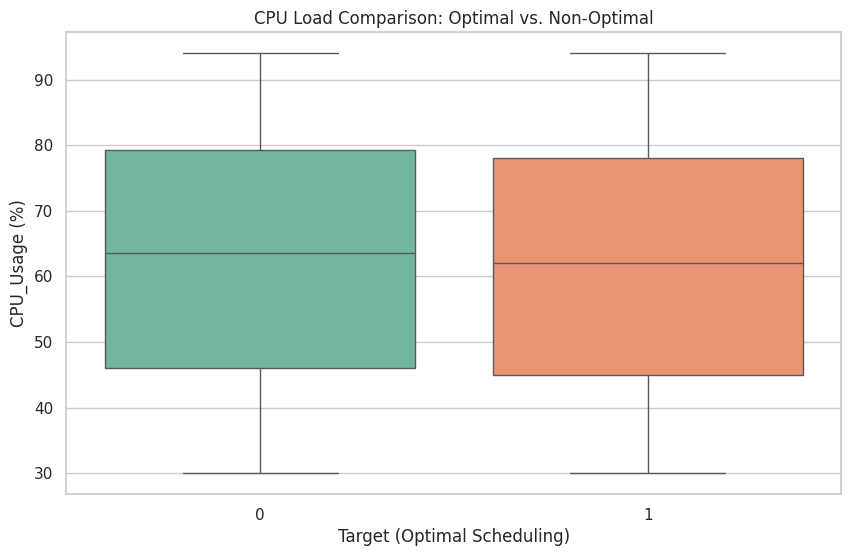

In [43]:
plt.figure()
sns.boxplot(x='Target (Optimal Scheduling)', y='CPU_Usage (%)', data=df, palette='Set2')
plt.title('CPU Load Comparison: Optimal vs. Non-Optimal')
plt.show()

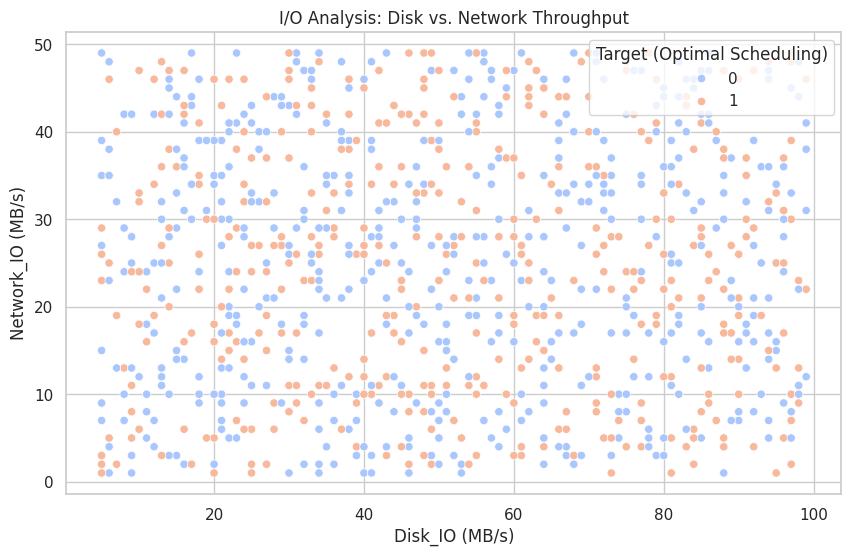

In [44]:
plt.figure()
sns.scatterplot(x='Disk_IO (MB/s)', y='Network_IO (MB/s)', hue='Target (Optimal Scheduling)', data=df, palette='coolwarm')
plt.title('I/O Analysis: Disk vs. Network Throughput')
plt.show()

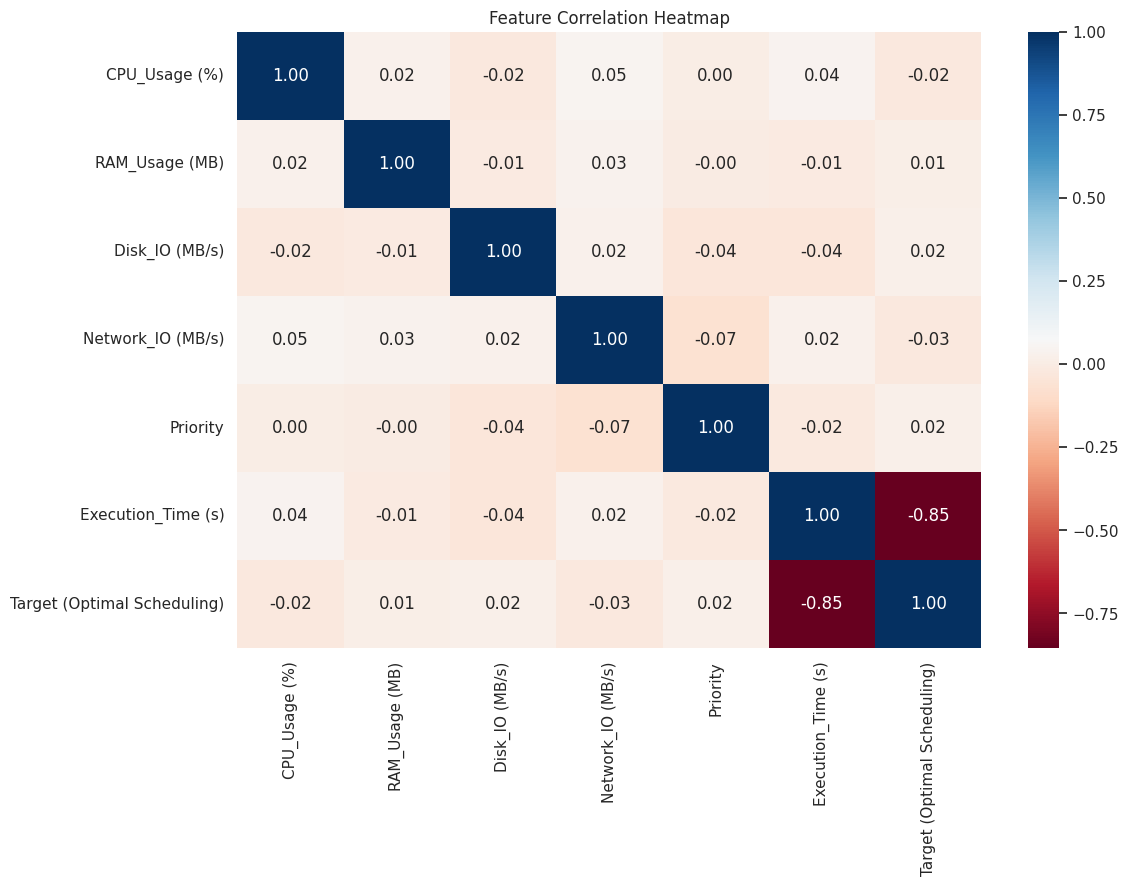

In [45]:
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['Task_ID', 'VM_ID']).corr()
sns.heatmap(corr, cmap='RdBu', annot=True, fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [46]:
# ==========================================
# 4. PREPROCESSING & OVERSAMPLING
# ==========================================
print("\nStep 3: Preparing data and applying Random Over Sampling...")

# Define Features and Target
X = df.drop(columns=['Task_ID', 'VM_ID', 'Target (Optimal Scheduling)'])
y = df['Target (Optimal Scheduling)']

# Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Random Over Sampling to balance the classes
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print(f"Training set balanced. Original counts: {y_train.value_counts().to_dict()}")
print(f"Resampled counts: {y_train_resampled.value_counts().to_dict()}")


Step 3: Preparing data and applying Random Over Sampling...
Training set balanced. Original counts: {0: 440, 1: 360}
Resampled counts: {0: 440, 1: 440}


In [47]:
# ==========================================
# 5. MODEL TRAINING & EVALUATION
# ==========================================
print("\nStep 4: Training machine learning models...")

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42)
}

results = []

for name, model in models.items():
    # Fit model
    model.fit(X_train_scaled, y_train_resampled)
    # Predict
    y_pred = model.predict(X_test_scaled)

    # Calculate Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })


Step 4: Training machine learning models...



--- FINAL ALGORITHM PERFORMANCE RANKING ---
                 Model  Accuracy  F1-Score  Precision    Recall
1        Random Forest     1.000  1.000000   1.000000  1.000000
2    Gradient Boosting     1.000  1.000000   1.000000  1.000000
3        Decision Tree     1.000  1.000000   1.000000  1.000000
4  Logistic Regression     0.995  0.994286   1.000000  0.988636
5                  SVM     0.965  0.960000   0.965517  0.954545
6                  KNN     0.945  0.936416   0.952941  0.920455


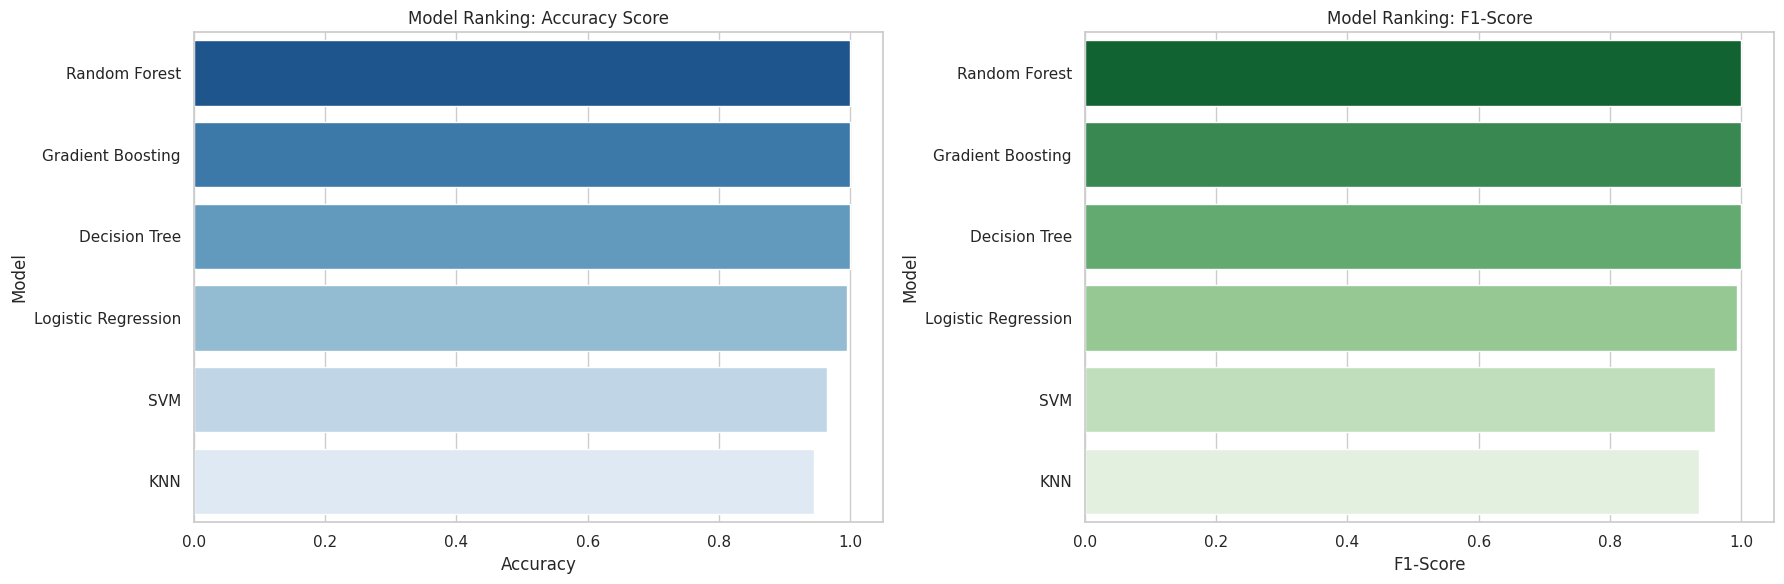


Workflow Complete. You can now use the best performing model for predictions.


In [48]:
# ==========================================
# 6. RANKING & COMPARISON
# ==========================================
# Create Rank Table
rank_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
rank_df.index += 1

print("\n--- FINAL ALGORITHM PERFORMANCE RANKING ---")
print(rank_df)

# Visual Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Accuracy', y='Model', data=rank_df, palette='Blues_r', ax=ax1)
ax1.set_title('Model Ranking: Accuracy Score')

sns.barplot(x='F1-Score', y='Model', data=rank_df, palette='Greens_r', ax=ax2)
ax2.set_title('Model Ranking: F1-Score')

plt.tight_layout()
plt.show()

print("\nWorkflow Complete. You can now use the best performing model for predictions.")